In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plotting style
plt.style.use('fivethirtyeight')
sns.set_palette("husl")

# --- 1. DATA LOADING ---
# Ensure you have the dataset in your /data folder
DATA_PATH = "../data/WA_Fn-UseC_-Telco-Customer-Churn.csv"

# For this execution, we'll load directly from the source if local file isn't found
try:
    df = pd.read_csv(DATA_PATH)
except FileNotFoundError:
    url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
    df = pd.read_csv(url)
    print("Downloaded data from remote source.")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# --- 2. ETL & CLEANING (Student 1 Focus) ---
def clean_telco_data(data):
    """
    Performs essential cleaning for the Telco dataset.
    """
    temp_df = data.copy()
    
    # TotalCharges contains empty strings ' ' which prevents numeric conversion
    # We replace them with NaN then cast to float
    temp_df['TotalCharges'] = temp_df['TotalCharges'].replace(' ', np.nan)
    temp_df['TotalCharges'] = temp_df['TotalCharges'].astype(float)
    
    # Fill missing TotalCharges: tenure * MonthlyCharges is a safe approximation
    temp_df['TotalCharges'] = temp_df['TotalCharges'].fillna(temp_df['tenure'] * temp_df['MonthlyCharges'])
    
    # Convert 'No internet service' and 'No phone service' to 'No' for simplicity
    cols_to_fix = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                   'TechSupport', 'StreamingTV', 'StreamingMovies']
    for col in cols_to_fix:
        temp_df[col] = temp_df[col].replace('No internet service', 'No')
        
    # Drop CustomerID - not useful for ML
    temp_df.drop('customerID', axis=1, inplace=True)
    
    return temp_df

df_clean = clean_telco_data(df)
print(f"Cleaning complete. Shape: {df_clean.shape}")

Cleaning complete. Shape: (7043, 20)


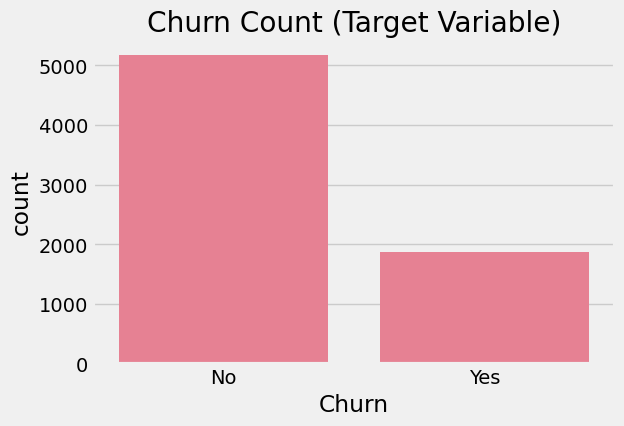

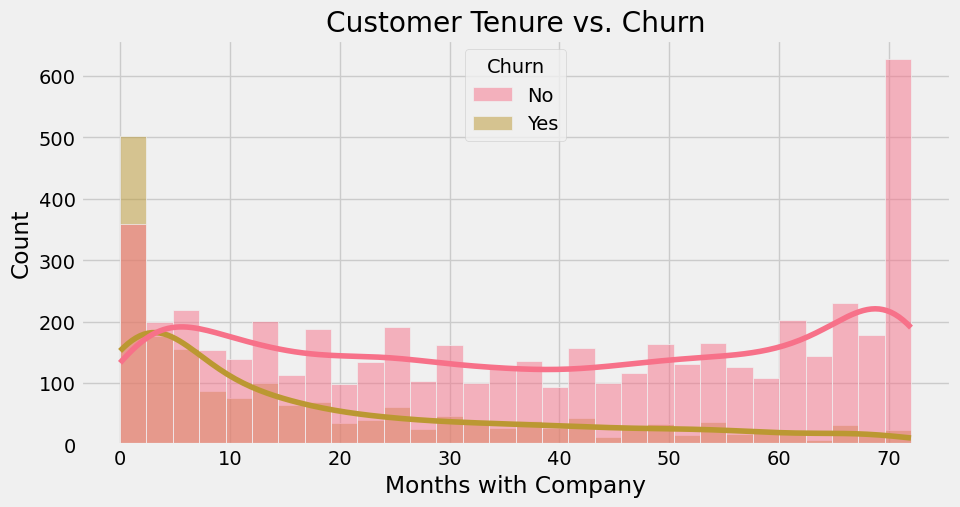

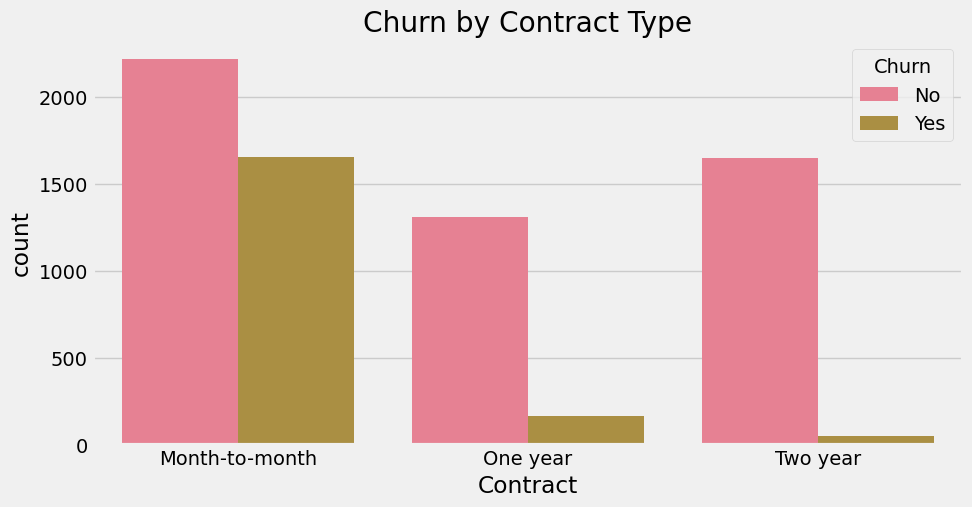

/var/folders/4l/s10rsgls1mlbch0mz5s9cnlh0000gn/T/ipykernel_39607/831910091.py:26: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_clean[df_clean['Churn'] == 'Yes']['MonthlyCharges'], label='Churn: Yes', shade=True)
/var/folders/4l/s10rsgls1mlbch0mz5s9cnlh0000gn/T/ipykernel_39607/831910091.py:27: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_clean[df_clean['Churn'] == 'No']['MonthlyCharges'], label='Churn: No', shade=True)


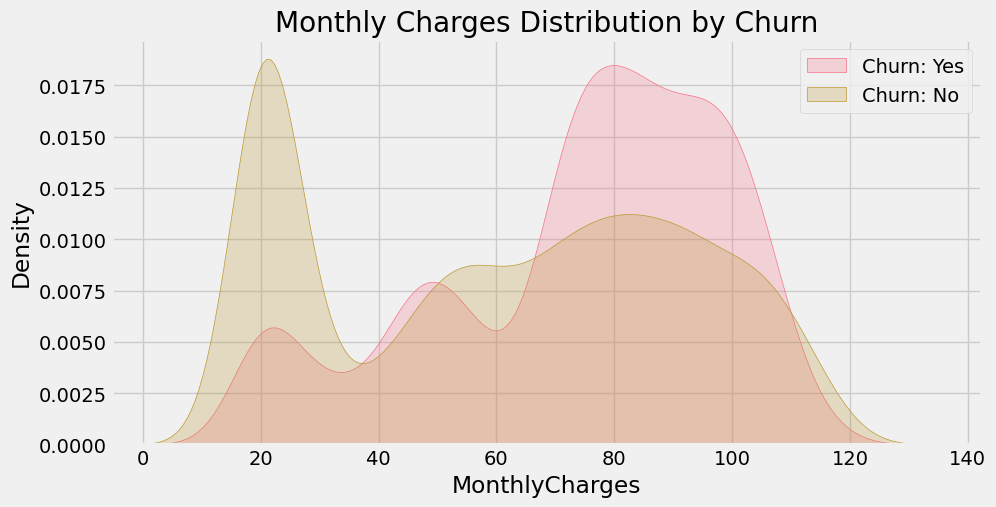

In [4]:
# --- 3. EXPLORATORY DATA ANALYSIS (Student 2 Focus) ---

# 3.1 Churn Overview
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df_clean)
plt.title('Churn Count (Target Variable)')
plt.show()

# 3.2 Tenure vs. Churn (The most critical driver)
plt.figure(figsize=(10, 5))
sns.histplot(data=df_clean, x='tenure', hue='Churn', kde=True, bins=30)
plt.title('Customer Tenure vs. Churn')
plt.xlabel('Months with Company')
plt.show()
# Insight: High churn in the first 1-6 months; retention stabilizes after 2 years.

# 3.3 Contract Type Analysis
plt.figure(figsize=(10, 5))
sns.countplot(x='Contract', hue='Churn', data=df_clean)
plt.title('Churn by Contract Type')
plt.show()
# Insight: Month-to-month contracts are the highest risk segment.

# 3.4 Monthly Charges Distribution
plt.figure(figsize=(10, 5))
sns.kdeplot(df_clean[df_clean['Churn'] == 'Yes']['MonthlyCharges'], label='Churn: Yes', shade=True)
sns.kdeplot(df_clean[df_clean['Churn'] == 'No']['MonthlyCharges'], label='Churn: No', shade=True)
plt.title('Monthly Charges Distribution by Churn')
plt.legend()
plt.show()

In [5]:
# --- 4. EXPORT FOR WEEK 2 ---
# Save the cleaned data so we don't have to clean it again next week
os.makedirs('../data', exist_ok=True)
df_clean.to_csv('../data/cleaned_churn_data.csv', index=False)
print("Cleaned data saved to /data/cleaned_churn_data.csv")

Cleaned data saved to /data/cleaned_churn_data.csv
